# TDABM method figures

Synthetic examples illustrate overlapping covers, graph construction and the effect of radius on resolution.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import TwoSlopeNorm
import networkx as nx
import statsmodels.api as sm
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
import pyballmapper as pbm

HERE = Path.cwd().resolve()
if (HERE / "results").is_dir():
    FIGURES = HERE / "results" / "figures"
elif (HERE.parent / "results").is_dir():
    FIGURES = HERE.parent / "results" / "figures"
elif (HERE / "upload").is_dir():
    FIGURES = HERE / "upload"
else:
    FIGURES = HERE / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 300, 'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10})

## 1. A point cloud and an overlapping cover

Standardise two synthetic characteristics and select landmarks from uncovered points. Each ball includes all points within the radius, allowing overlap. The final panel retains landmark coordinates.


In [2]:
rng = np.random.default_rng(42)
left = rng.normal(loc=(-1.7, -0.3), scale=(0.72, 0.62), size=(85, 2))
bridge = rng.normal(loc=(0.0, 0.1), scale=(0.55, 0.35), size=(35, 2))
right = rng.normal(loc=(1.8, 0.55), scale=(0.75, 0.60), size=(85, 2))
X2 = pd.DataFrame(np.vstack([left, bridge, right]), columns=['Characteristic 1', 'Characteristic 2'])
X2.loc[:, :] = StandardScaler().fit_transform(X2)
eps_cover = 0.78
D = pairwise_distances(X2)
uncovered = set(range(len(X2)))
landmarks = []
memberships = []
while uncovered:
    centre = min(uncovered)
    members = np.flatnonzero(D[centre] <= eps_cover)
    landmarks.append(centre)
    memberships.append(set(members.tolist()))
    uncovered.difference_update(members.tolist())
print(f'{len(X2)} points covered by {len(landmarks)} balls; epsilon={eps_cover}')

205 points covered by 17 balls; epsilon=0.78


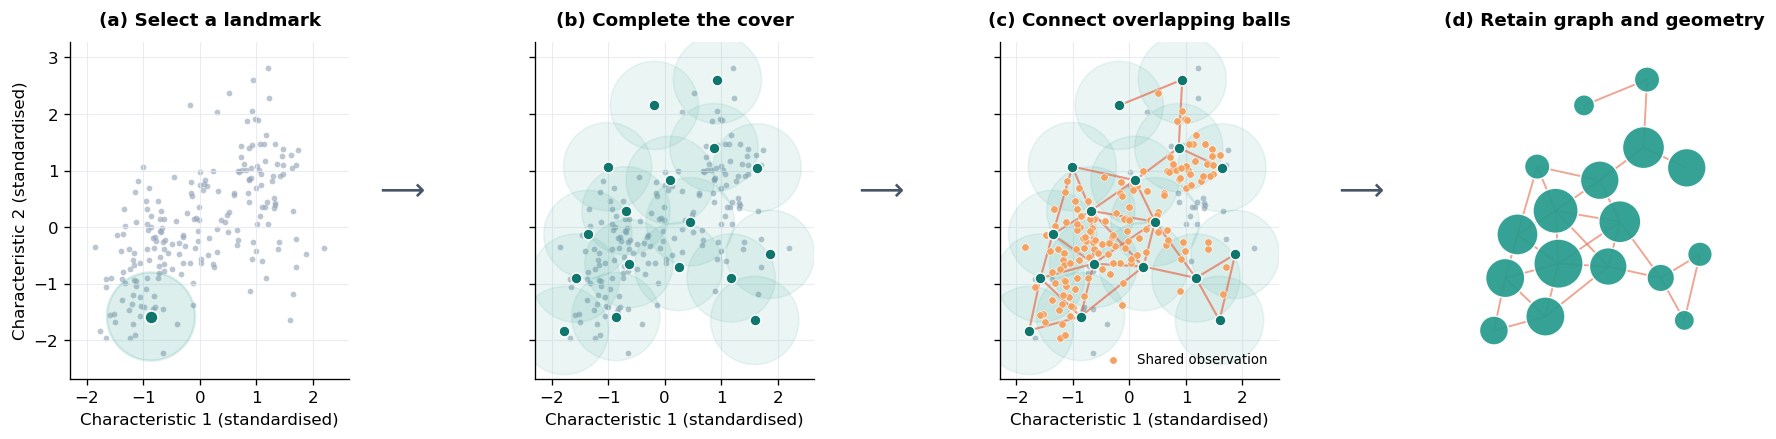

In [3]:
cover_edges = [(i, j) for i in range(len(memberships)) for j in range(i + 1, len(memberships)) if memberships[i] & memberships[j]]
shared_points = set().union(*(memberships[i] & memberships[j] for i, j in cover_edges))
graph_cover = nx.Graph()
graph_cover.add_nodes_from(range(len(landmarks)))
graph_cover.add_edges_from(cover_edges)

fig, axes = plt.subplots(1, 4, figsize=(15.8, 4.25))
point_colour, cover_colour, edge_colour = '#94a3b8', '#2a9d8f', '#e76f51'
titles = ['(a) Select a landmark', '(b) Complete the cover', '(c) Connect overlapping balls', '(d) Retain graph and geometry']

for ax in axes[:3]:
    ax.scatter(X2.iloc[:, 0], X2.iloc[:, 1], s=12, color=point_colour, alpha=0.62, linewidth=0, zorder=1)
    ax.set_xlim(X2.iloc[:, 0].min() - 0.45, X2.iloc[:, 0].max() + 0.45)
    ax.set_ylim(X2.iloc[:, 1].min() - 0.45, X2.iloc[:, 1].max() + 0.45)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(color='#e2e8f0', linewidth=0.65, alpha=0.75)
    ax.spines[['top', 'right']].set_visible(False)

first = landmarks[0]
axes[0].add_patch(Circle(X2.iloc[first].to_numpy(), eps_cover, facecolor=cover_colour, edgecolor=cover_colour, alpha=0.16, lw=1.5, zorder=2))
axes[0].scatter(*X2.iloc[first], s=62, marker='o', color='#0f766e', edgecolor='white', linewidth=1.0, zorder=4)

for ax in axes[1:3]:
    for idx in landmarks:
        ax.add_patch(Circle(X2.iloc[idx].to_numpy(), eps_cover, facecolor=cover_colour, edgecolor=cover_colour, alpha=0.09, lw=1.0, zorder=2))
    ax.scatter(X2.iloc[landmarks, 0], X2.iloc[landmarks, 1], s=42, color='#0f766e', edgecolor='white', linewidth=0.8, zorder=5)

for i, j in cover_edges:
    axes[2].plot([X2.iloc[landmarks[i], 0], X2.iloc[landmarks[j], 0]], [X2.iloc[landmarks[i], 1], X2.iloc[landmarks[j], 1]], color=edge_colour, alpha=0.72, lw=1.25, zorder=3)
axes[2].scatter(X2.iloc[list(shared_points), 0], X2.iloc[list(shared_points), 1], s=20, color='#f4a261', edgecolor='white', linewidth=0.35, zorder=4, label='Shared observation')
axes[2].legend(loc='lower right', frameon=False, fontsize=8)

layout = {node: X2.iloc[landmarks[node]].to_numpy() for node in graph_cover.nodes}
node_sizes = [120 + 14 * len(memberships[node]) for node in graph_cover.nodes]
nx.draw_networkx_edges(graph_cover, layout, ax=axes[3], edge_color=edge_colour, width=1.15, alpha=0.62)
nx.draw_networkx_nodes(graph_cover, layout, ax=axes[3], node_size=node_sizes, node_color=cover_colour, edgecolors='white', linewidths=0.9, alpha=0.95)
axes[3].set_xlim(axes[2].get_xlim())
axes[3].set_ylim(axes[2].get_ylim())
axes[3].set_aspect('equal', adjustable='box')
axes[3].axis('off')

for ax, title in zip(axes, titles):
    ax.set_title(title, pad=10, fontweight='semibold')
for ax in axes[:3]:
    ax.set_xlabel('Characteristic 1 (standardised)')
axes[0].set_ylabel('Characteristic 2 (standardised)')
axes[1].set_yticklabels([])
axes[2].set_yticklabels([])
for x in (0.252, 0.505, 0.758):
    fig.text(x, 0.53, r'$\longrightarrow$', color='#475569', fontsize=19, ha='center', va='center')
fig.subplots_adjust(left=0.055, right=0.985, bottom=0.16, top=0.82, wspace=0.26)
fig.savefig(FIGURES / 'tdabm_appendix_cover.png', bbox_inches='tight', facecolor='white')
plt.show()

## 2. From cover to graph

Each ball becomes a node, and shared observations create edges. Node size reflects membership and colour shows mean characteristic 1. The spring layout has no substantive axes.


D:\anaconda\Lib\site-packages\matplotlib\patches.py:1648: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center = (self.convert_xunits(self._center[0]),
D:\anaconda\Lib\site-packages\matplotlib\patches.py:1649: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.convert_yunits(self._center[1]))


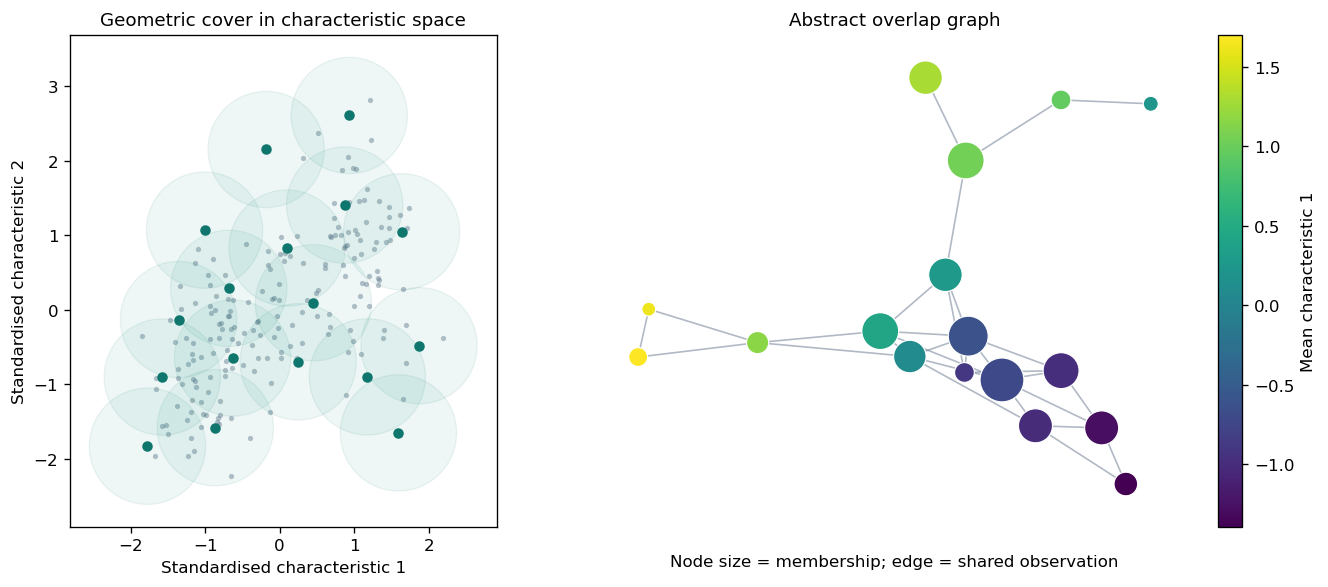

In [4]:
cover_graph = nx.Graph()
for k, members in enumerate(memberships):
    cover_graph.add_node(k, size=len(members))
for k in range(len(memberships)):
    for ell in range(k + 1, len(memberships)):
        overlap = len(memberships[k].intersection(memberships[ell]))
        if overlap:
            cover_graph.add_edge(k, ell, overlap=overlap)
node_sizes = np.array([cover_graph.nodes[k]['size'] for k in cover_graph.nodes])
node_colours = [X2.iloc[list(memberships[k]), 0].mean() for k in cover_graph.nodes]
pos = nx.spring_layout(cover_graph, seed=8, k=0.58)
fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.0))
axes[0].scatter(X2.iloc[:, 0], X2.iloc[:, 1], s=10, color='#64748b', alpha=0.45, linewidth=0)
for order, idx in enumerate(landmarks):
    axes[0].add_patch(Circle(X2.iloc[idx], eps_cover, facecolor='#2a9d8f', edgecolor='#15736a', alpha=0.08, lw=0.8))
    axes[0].scatter(*X2.iloc[idx], s=28, color='#0f766e', zorder=3)
axes[0].set(title='Geometric cover in characteristic space', xlabel='Standardised characteristic 1', ylabel='Standardised characteristic 2')
axes[0].set_aspect('equal', adjustable='box')
nx.draw_networkx_edges(cover_graph, pos, ax=axes[1], width=1.0, alpha=0.5, edge_color='#64748b')
nodes = nx.draw_networkx_nodes(cover_graph, pos, ax=axes[1], node_size=45 + node_sizes * 12, node_color=node_colours, cmap='viridis', edgecolors='white', linewidths=0.7)
axes[1].set_title('Abstract overlap graph')
axes[1].text(0.5, -0.08, 'Node size = membership; edge = shared observation', transform=axes[1].transAxes, ha='center')
axes[1].axis('off')
fig.colorbar(nodes, ax=axes[1], fraction=0.046, pad=0.02, label='Mean characteristic 1')
fig.tight_layout()
fig.savefig(FIGURES / 'tdabm_appendix_graph.png', bbox_inches='tight', facecolor='white')
plt.show()

## 3. Radius as a resolution parameter

Compare three radius using the same observations, synthetic outcome and colour scale. Smaller radius retain detail but may fragment the graph; larger radii form broader groups.


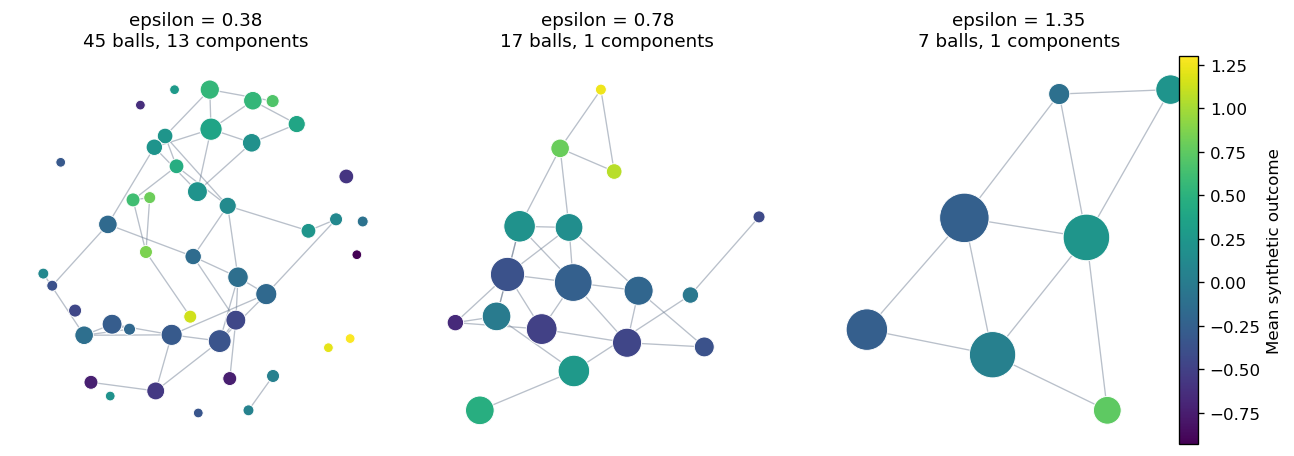

In [5]:
colour_df = pd.DataFrame({'Outcome': 0.55 * X2.iloc[:, 0] - 0.25 * X2.iloc[:, 1]})
eps_values = [0.38, 0.78, 1.35]
fig, axes = plt.subplots(1, 3, figsize=(12.8, 4.2))
for ax, eps_value in zip(axes, eps_values):
    bm = pbm.BallMapper(X=X2, eps=eps_value, coloring_df=colour_df)
    graph = bm.Graph
    layout = nx.spring_layout(graph, seed=11, k=0.62)
    sizes = np.array([graph.nodes[n]['size'] for n in graph.nodes])
    colours = np.array([graph.nodes[n]['Outcome'] for n in graph.nodes])
    nx.draw_networkx_edges(graph, layout, ax=ax, width=0.8, alpha=0.45, edge_color='#64748b')
    nx.draw_networkx_nodes(graph, layout, ax=ax, node_size=25 + sizes * 9, node_color=colours, cmap='viridis',                            vmin=colour_df['Outcome'].min(), vmax=colour_df['Outcome'].max(),                            edgecolors='white', linewidths=0.55)
    components = nx.number_connected_components(graph)
    ax.set_title(f'epsilon = {eps_value}\n{len(graph)} balls, {components} components')
    ax.axis('off')
smappable = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(colour_df['Outcome'].min(), colour_df['Outcome'].max()))
fig.colorbar(smappable, ax=axes, fraction=0.02, pad=0.02, label='Mean synthetic outcome')
fig.subplots_adjust(wspace=0.12, right=0.90)
fig.savefig(FIGURES / 'tdabm_appendix_epsilon.png', bbox_inches='tight', facecolor='white')
plt.show()